In [12]:
import sys
!{sys.executable} -m pip install selenium pandas matplotlib beautifulsoup4


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ROG\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [23]:
import requests
import pandas as pd
import time
from urllib.parse import quote, urljoin
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

LIMIT = 220
HEADERS = {"User-Agent": "Mozilla/5.0"}

# =========================
# Dataset 1: V&A Textile API
# =========================

def scrape_va_api(limit=200):
    keywords = [
        "textile", "weaving", "embroidery", "tapestry",
        "fabric", "silk", "lace", "carpet",
        "wool", "cotton", "thread", "red textile"
    ]

    rows = []
    seen = set()

    for kw in keywords:
        page = 1

        while len(rows) < limit and page <= 5:
            url = (
                "https://api.vam.ac.uk/v2/objects/search?"
                f"q={quote(kw)}&page_size=100&page={page}"
            )

            print("Opening V&A API:", url)

            try:
                data = requests.get(url, headers=HEADERS, timeout=20).json()
            except Exception as e:
                print("Skip:", e)
                break

            records = data.get("records", [])

            if not records:
                break

            for r in records:
                system_number = r.get("systemNumber")
                if not system_number or system_number in seen:
                    continue

                title = r.get("_primaryTitle") or r.get("objectType") or "Untitled object"
                object_type = r.get("objectType", "")
                date = r.get("_primaryDate", "")
                maker = ""
                if isinstance(r.get("_primaryMaker"), dict):
                    maker = r["_primaryMaker"].get("name", "")

                image_url = None
                images = r.get("_images", {})
                if isinstance(images, dict):
                    image_url = images.get("_primary_thumbnail")

                link = f"https://collections.vam.ac.uk/item/{system_number}/"

                rows.append({
                    "title": title,
                    "object_type": object_type,
                    "maker": maker,
                    "date": date,
                    "image_url": image_url,
                    "link": link,
                    "source": "V&A Textiles Collection",
                    "search_keyword": kw
                })

                seen.add(system_number)

                if len(rows) >= limit:
                    break

            page += 1
            time.sleep(0.5)

        if len(rows) >= limit:
            break

    return pd.DataFrame(rows)


df_textile = scrape_va_api(LIMIT)
df_textile.to_csv("dataset_1_va_textile.csv", index=False, encoding="utf-8-sig")


# =========================
# Selenium helper
# =========================

options = Options()
options.add_argument("--disable-search-engine-choice-screen")
driver = webdriver.Chrome(options=options)

def scroll_page(times=10):
    for i in range(times):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)

def clean_title(title):
    return " ".join(str(title).split()).strip()

def is_bad_title(title):
    bad = [
        "home", "search", "collections", "browse", "about",
        "contact", "privacy", "cookies", "terms", "login",
        "sign up", "newsletter", "submit", "advertise",
        "news", "projects", "organisations"
    ]
    t = title.lower()
    return len(t) < 15 or any(x in t for x in bad)


# =========================
# Dataset 2: ArchDaily
# =========================

def scrape_archdaily(limit=200):
    urls = [
        "https://www.archdaily.com/search/projects/categories/pavilion",
        "https://www.archdaily.com/search/projects/categories/cultural-architecture",
        "https://www.archdaily.com/search/projects/categories/public-architecture",
        "https://www.archdaily.com/search/projects/categories/installations-structures",
        "https://www.archdaily.com/search/projects/categories/museums-and-libraries"
    ]

    rows = []
    seen = set()

    for url in urls:
        print("Opening ArchDaily:", url)
        driver.get(url)
        time.sleep(5)
        scroll_page(10)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        for a in soup.find_all("a"):
            title = clean_title(a.get_text(" ", strip=True))
            href = a.get("href")

            if not href or not title:
                continue

            link = urljoin("https://www.archdaily.com", href)

            if not link.startswith("https://www.archdaily.com"):
                continue
            if any(x in link.lower() for x in ["/search/", "/tag/", "/architecture-news/", "/contact", "#"]):
                continue
            if link in seen:
                continue
            if is_bad_title(title):
                continue

            first_part = link.replace("https://www.archdaily.com/", "").split("/")[0]
            if not first_part[:3].isdigit():
                continue

            rows.append({
                "title": title,
                "link": link,
                "source": "ArchDaily"
            })

            seen.add(link)

            if len(rows) >= limit:
                return pd.DataFrame(rows)

    return pd.DataFrame(rows)


df_arch = scrape_archdaily(LIMIT)
df_arch.to_csv("dataset_2_archdaily.csv", index=False, encoding="utf-8-sig")


# =========================
# Dataset 3: NOWNESS
# =========================

def scrape_nowness(limit=200):
    urls = [
        "https://www.nowness.com/topic/dance",
        "https://www.nowness.com/topic/performance",
        "https://www.nowness.com/category/music-and-dance",
        "https://www.nowness.com/search?q=dance",
        "https://www.nowness.com/search?q=movement",
        "https://www.nowness.com/search?q=body",
        "https://www.nowness.com/search?q=performance",
        "https://www.nowness.com/search?q=ritual",
        "https://www.nowness.com/search?q=gesture",
        "https://www.nowness.com/search?q=dancer",
        "https://www.nowness.com/search?q=choreography",
        "https://www.nowness.com/search?q=motion",
        "https://www.nowness.com/search?q=physical",
        "https://www.nowness.com/search?q=music",
        "https://www.nowness.com/search?q=body%20language"
    ]

    rows = []
    seen = set()

    for url in urls:
        print("Opening NOWNESS:", url)
        driver.get(url)
        time.sleep(5)
        scroll_page(12)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        for a in soup.find_all("a"):
            title = clean_title(a.get_text(" ", strip=True))
            href = a.get("href")

            if not href or not title:
                continue

            link = urljoin("https://www.nowness.com", href)

            if not link.startswith("https://www.nowness.com"):
                continue
            if any(x in link.lower() for x in ["/search", "/about", "/contact", "#"]):
                continue
            if link in seen:
                continue
            if is_bad_title(title):
                continue

            text = (title + " " + link).lower()
            keys = [
                "dance", "movement", "body", "performance",
                "motion", "choreography", "ritual", "music",
                "dancer", "gesture", "physical", "film"
            ]

            if not any(k in text for k in keys):
                continue

            rows.append({
                "title": title,
                "link": link,
                "source": "NOWNESS"
            })

            seen.add(link)

            if len(rows) >= limit:
                return pd.DataFrame(rows)

    return pd.DataFrame(rows)


df_move = scrape_nowness(LIMIT)
df_move.to_csv("dataset_3_nowness.csv", index=False, encoding="utf-8-sig")

driver.quit()

print("V&A Textile:", len(df_textile))
print("Architecture:", len(df_arch))
print("Movement:", len(df_move))

display(df_textile.head(10))
display(df_arch.head(10))
display(df_move.head(10))

Opening V&A API: https://api.vam.ac.uk/v2/objects/search?q=textile&page_size=100&page=1
Opening V&A API: https://api.vam.ac.uk/v2/objects/search?q=textile&page_size=100&page=2
Opening V&A API: https://api.vam.ac.uk/v2/objects/search?q=textile&page_size=100&page=3
Opening ArchDaily: https://www.archdaily.com/search/projects/categories/pavilion
Opening ArchDaily: https://www.archdaily.com/search/projects/categories/cultural-architecture
Opening NOWNESS: https://www.nowness.com/topic/dance
Opening NOWNESS: https://www.nowness.com/topic/performance
Opening NOWNESS: https://www.nowness.com/category/music-and-dance
Opening NOWNESS: https://www.nowness.com/search?q=dance
Opening NOWNESS: https://www.nowness.com/search?q=movement
Opening NOWNESS: https://www.nowness.com/search?q=body
Opening NOWNESS: https://www.nowness.com/search?q=performance
Opening NOWNESS: https://www.nowness.com/search?q=ritual
Opening NOWNESS: https://www.nowness.com/search?q=gesture
Opening NOWNESS: https://www.nowness

,title,object_type,maker,date,image_url,link,source,search_keyword
0,Design for textile,Textile design,"Grant, Duncan",c. 1933,https://framemark.vam.ac.uk/collections/2016JG...,https://collections.vam.ac.uk/item/O552918/,V&A Textiles Collection,textile
1,Design for textile,Textile design,"Grant, Duncan",c. 1933,https://framemark.vam.ac.uk/collections/2016JG...,https://collections.vam.ac.uk/item/O552915/,V&A Textiles Collection,textile
2,Design for textile,Textile design,"Grant, Duncan",c. 1933,https://framemark.vam.ac.uk/collections/2016JG...,https://collections.vam.ac.uk/item/O552920/,V&A Textiles Collection,textile
3,Design for textile,Textile design,"Grant, Duncan",c. 1933,https://framemark.vam.ac.uk/collections/2016JR...,https://collections.vam.ac.uk/item/O552919/,V&A Textiles Collection,textile
4,Design for textile,Textile design,"Grant, Duncan",c. 1933,https://framemark.vam.ac.uk/collections/2016JG...,https://collections.vam.ac.uk/item/O552912/,V&A Textiles Collection,textile
5,Design for textile,Textile design,"Grant, Duncan",c. 1933,NaN,https://collections.vam.ac.uk/item/O552914/,V&A Textiles Collection,textile
6,Design for textile,Textile design,Vanessa Bell,ca. 1934,https://framemark.vam.ac.uk/collections/2016JG...,https://collections.vam.ac.uk/item/O552913/,V&A Textiles Collection,textile
7,Design for textile,Textile design,Vanessa Bell,c. 1934,https://framemark.vam.ac.uk/collections/2024NT...,https://collections.vam.ac.uk/item/O552917/,V&A Textiles Collection,textile
8,Design for textile,Textile design,Vanessa Bell,ca. 1934,https://framemark.vam.ac.uk/collections/2024NT...,https://collections.vam.ac.uk/item/O552916/,V&A Textiles Collection,textile
9,Daphne and Apollo,Textile,Duncan Grant,1932,https://framemark.vam.ac.uk/collections/2006BF...,https://collections.vam.ac.uk/item/O199319/,V&A Textiles Collection,textile


,title,link,source
0,Pavilion Shell Book Pavilion / LUO studio,https://www.archdaily.com/1040851/shell-book-p...,ArchDaily
1,Pavilion The German Pavilion at the Kerala Lit...,https://www.archdaily.com/1040258/the-german-p...,ArchDaily
2,Cultural Architecture Light Pavilion / DRAWING...,https://www.archdaily.com/1039978/light-pavili...,ArchDaily
3,Pavilion Resting Pavilion in Osaka Expo / MIDW,https://www.archdaily.com/1039766/resting-pavi...,ArchDaily
4,"Pavilion ""Echo of the ruins"" Open-Air Museum o...",https://www.archdaily.com/1039649/echo-of-the-...,ArchDaily
5,Cultural Architecture Sayuwon Park Performance...,https://www.archdaily.com/1039718/sayuwon-park...,ArchDaily
6,Mixed Use Architecture Casa Wabi Mushroom Pavi...,https://www.archdaily.com/1039505/casa-wabi-mu...,ArchDaily
7,Pavilion L’Ile Folie / MARC FORNES + THEVERYMANY,https://www.archdaily.com/1039510/lile-folie-m...,ArchDaily
8,Installations & Structures Unscripted Pavilion...,https://www.archdaily.com/1039250/unscripted-p...,ArchDaily
9,Installations & Structures Pavilion TEUM / Koo...,https://www.archdaily.com/1039033/pavilion-teu...,ArchDaily


,title,link,source
0,​Labour of Love,https://www.nowness.com/topic/dance/labour-of-...,NOWNESS
1,​Just Dance: Good for the Soul,https://www.nowness.com/topic/dance/good-for-t...,NOWNESS
2,​Limber Up: City Swan,https://www.nowness.com/topic/dance/city-swan,NOWNESS
3,​HERD(mentality),https://www.nowness.com/topic/dance/herdmental...,NOWNESS
4,Break'in Through: Dany Dann,https://www.nowness.com/topic/dance/breakin-th...,NOWNESS
5,​Ebinum Brothers: A Better World,https://www.nowness.com/topic/dance/ebinum-bro...,NOWNESS
6,​Break’in Through,https://www.nowness.com/topic/dance/breakin-th...,NOWNESS
7,​NOWNESS Shorts: Casete Rojo,https://www.nowness.com/topic/dance/casete-roj...,NOWNESS
8,​An Invitation to Dream: Francesca Hayward,https://www.nowness.com/topic/dance/francesca-...,NOWNESS
9,​Non Dimenticare,https://www.nowness.com/topic/dance/non-diment...,NOWNESS


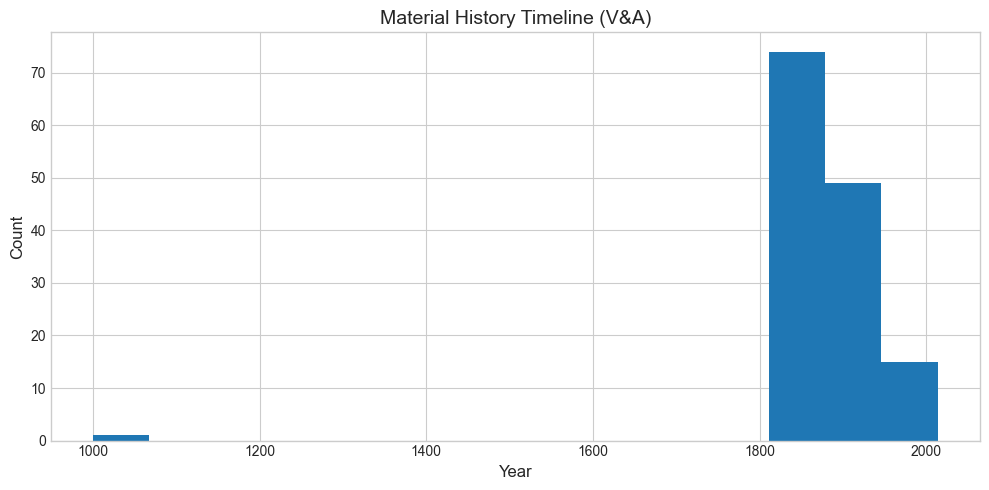

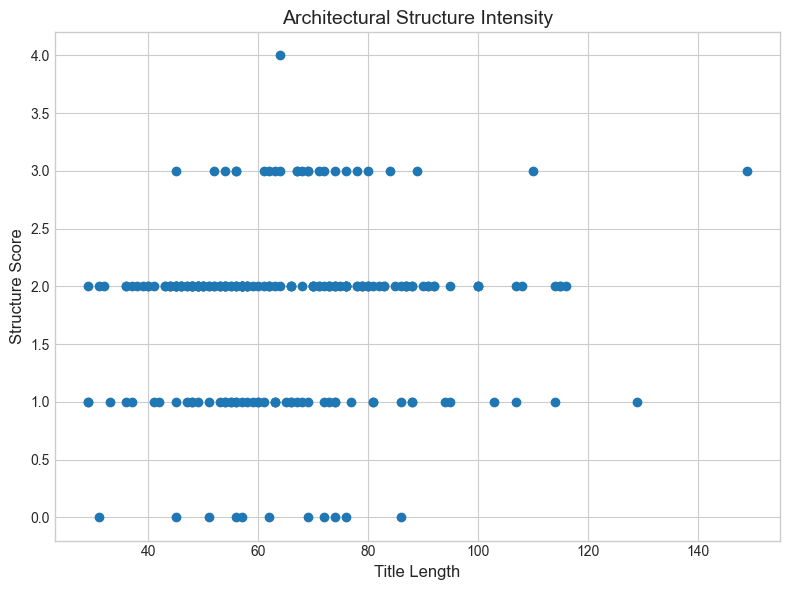

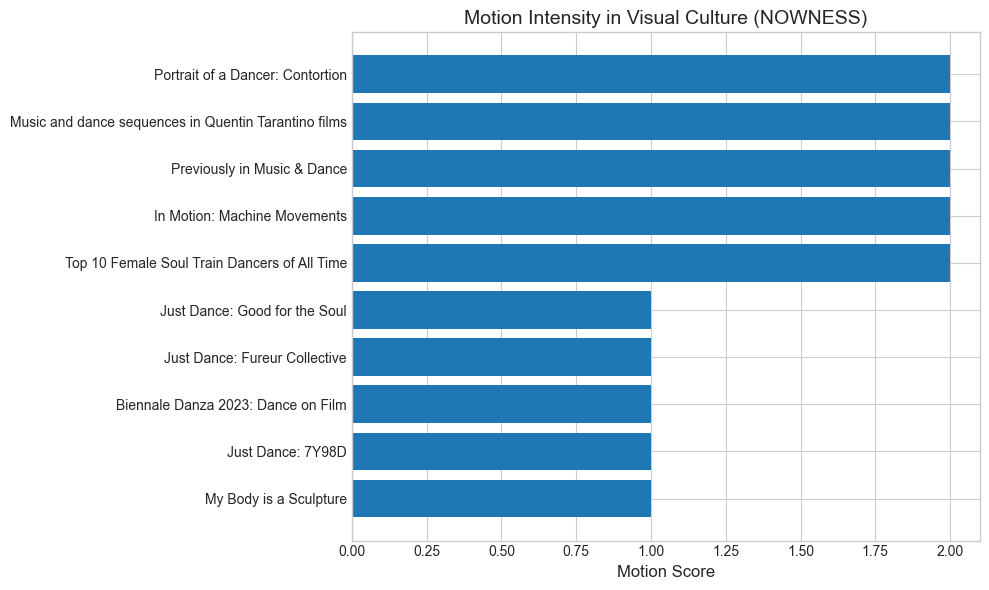

In [27]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# =========================
# Plot 1: V&A Date Distribution
# =========================

plt.figure(figsize=(10, 5))
plt.hist(years, bins=15)

plt.title("Material History Timeline (V&A)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()


# =========================
# Plot 2: ArchDaily Structure
# =========================

plt.figure(figsize=(8, 6))
plt.scatter(df_arch["title_length"], df_arch["structure_score"])

plt.title("Architectural Structure Intensity", fontsize=14)
plt.xlabel("Title Length", fontsize=12)
plt.ylabel("Structure Score", fontsize=12)

plt.tight_layout()
plt.show()


# =========================
# Plot 3: NOWNESS Motion
# （减少到10个 更干净）
# =========================

top_move = df_move.sort_values("motion_score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_move["title"], top_move["motion_score"])

plt.title("Motion Intensity in Visual Culture (NOWNESS)", fontsize=14)
plt.xlabel("Motion Score", fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
# =========================
# CELL 4 - IMAGE ANALYSIS
# =========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

IMAGE_DIR = "artist_images"

results = []

image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith((".jpg", ".png", ".jpeg"))]

print("Total images:", len(image_files))


for file in image_files:
    path = os.path.join(IMAGE_DIR, file)
    
    image = cv2.imread(path)
    
    if image is None:
        continue
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # -------------------------
    # 1. 红色比例 (red ratio)
    # -------------------------
    r = image_rgb[:,:,0]
    g = image_rgb[:,:,1]
    b = image_rgb[:,:,2]
    
    red_mask = (r > 120) & (g < 80) & (b < 80)
    red_ratio = np.sum(red_mask) / red_mask.size
    
    
    # -------------------------
    # 2. 边缘检测（线结构）
    # -------------------------
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    
    edge_density = np.sum(edges > 0) / edges.size
    
    
    # -------------------------
    # 3. skeleton（骨架）
    # -------------------------
    binary = edges > 0
    skeleton = skeletonize(binary)
    
    skeleton_length = np.sum(skeleton)
    
    
    # -------------------------
    # 保存结果
    # -------------------------
    results.append({
        "file": file,
        "red_ratio": red_ratio,
        "edge_density": edge_density,
        "skeleton_length": skeleton_length
    })


# 转成 DataFrame
import pandas as pd
df_img = pd.DataFrame(results)

print(df_img.head())

Total images: 30
          file  red_ratio  edge_density  skeleton_length
0   image1.jpg   0.187872      0.030689            10091
1  image10.jpg   0.052023      0.083969           132231
2  image11.jpg   0.031799      0.075590            50195
3  image12.jpg   0.019838      0.077796            46683
4  image13.jpg   0.153753      0.071727            18185


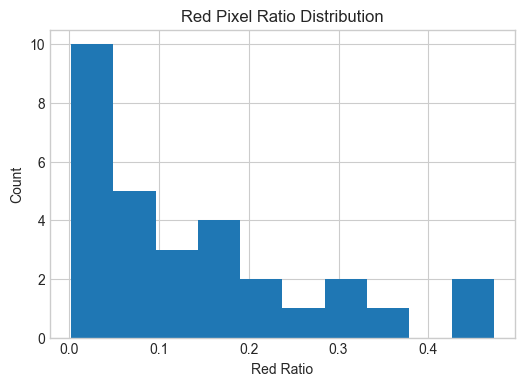

In [29]:
plt.figure(figsize=(6,4))
plt.hist(df_img["red_ratio"], bins=10)
plt.title("Red Pixel Ratio Distribution")
plt.xlabel("Red Ratio")
plt.ylabel("Count")
plt.show()

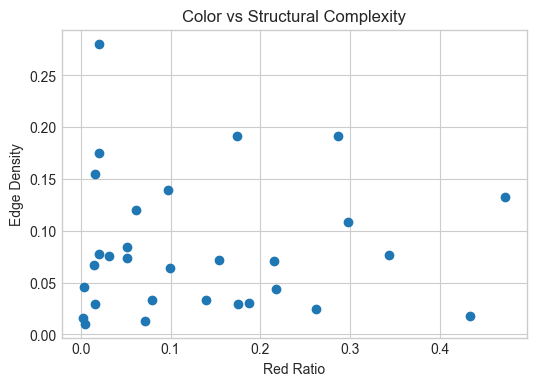

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(df_img["red_ratio"], df_img["edge_density"])
plt.title("Color vs Structural Complexity")
plt.xlabel("Red Ratio")
plt.ylabel("Edge Density")
plt.show()

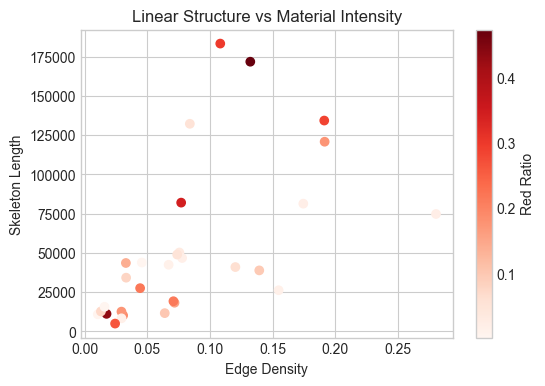

In [33]:
plt.figure(figsize=(6,4))

plt.scatter(
    df_img["edge_density"],
    df_img["skeleton_length"],
    c=df_img["red_ratio"], 
    cmap="Reds"
)

plt.colorbar(label="Red Ratio")

plt.title("Linear Structure vs Material Intensity")
plt.xlabel("Edge Density")
plt.ylabel("Skeleton Length")

plt.show()

In [44]:
import pandas as pd

df_va = pd.read_csv("df_va.csv")
df_arch = pd.read_csv("df_arch.csv")
df_move = pd.read_csv("df_move.csv")

print(len(df_va), len(df_arch), len(df_move))

220 220 160


In [45]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ROG\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 用 title 做分析
texts = list(df_va["title"].dropna()) + \
        list(df_arch["title"].dropna()) + \
        list(df_move["title"].dropna())

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(texts)

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (600, 1287)


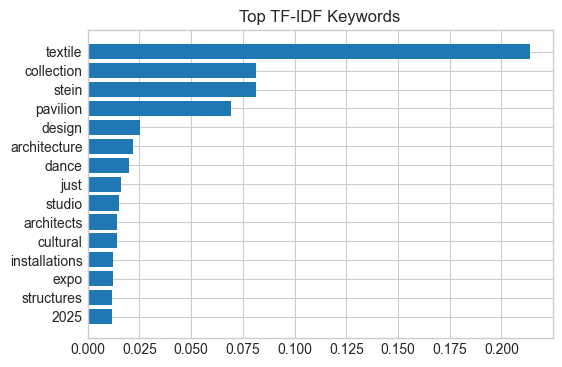

In [47]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
scores = np.mean(tfidf_matrix.toarray(), axis=0)

top_indices = np.argsort(scores)[-15:]
top_words = feature_names[top_indices]
top_scores = scores[top_indices]

plt.figure(figsize=(6,4))
plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Keywords")
plt.show()

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 用同样的 texts
vectorizer2 = CountVectorizer(stop_words='english')
count_matrix = vectorizer2.fit_transform(texts)

print("Count Vector shape:", count_matrix.shape)

# 计算相似度
similarity = cosine_similarity(count_matrix)

print("Similarity matrix shape:", similarity.shape)

Count Vector shape: (600, 1287)
Similarity matrix shape: (600, 600)


In [50]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ROG\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


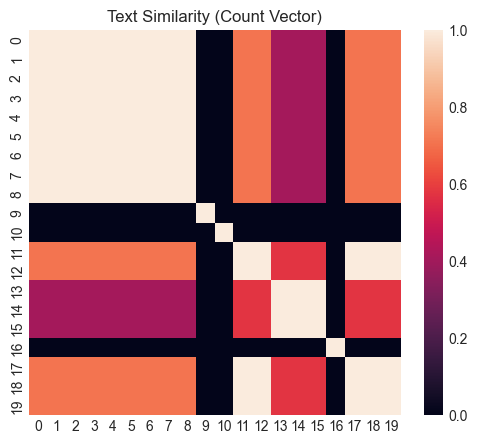

In [51]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(similarity[:20,:20])
plt.title("Text Similarity (Count Vector)")
plt.show()

In [66]:
import sys
!{sys.executable} -m pip install openai==0.28


   --------------- ------------------------ 3/8 [aiohappyeyeballs]
   ------------------------------ --------- 6/8 [aiohttp]
   ------------------------------ --------- 6/8 [aiohttp]
   ------------------------------ --------- 6/8 [aiohttp]
   ------------------------------ --------- 6/8 [aiohttp]
   ------------------------------ --------- 6/8 [aiohttp]
  Attempting uninstall: openai
   ------------------------------ --------- 6/8 [aiohttp]
    Found existing installation: openai 2.32.0
   ------------------------------ --------- 6/8 [aiohttp]
   ----------------------------------- ---- 7/8 [openai]
   ----------------------------------- ---- 7/8 [openai]
    Uninstalling openai-2.32.0:
   ----------------------------------- ---- 7/8 [openai]
      Successfully uninstalled openai-2.32.0
   ----------------------------------- ---- 7/8 [openai]
   ----------------------------------- ---- 7/8 [openai]
   ----------------------------------- ---- 7/8 [openai]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ROG\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
# Local generative interaction replacement
# It translates vectorised keywords into design actions without external API.

api_like_keywords = [
    "textile", "thread", "pavilion", "architecture", "dance",
    "structure", "movement", "body", "knot", "tension",
    "ritual", "weaving", "frame", "suspend", "connection"
]

design_rules = {
    "textile": "create layered surfaces",
    "thread": "extend linear elements through space",
    "pavilion": "form temporary spatial frames",
    "architecture": "organise lines into structural systems",
    "dance": "translate motion into curved paths",
    "structure": "increase support and connection points",
    "movement": "generate directional flow",
    "body": "respond to human scale and gesture",
    "knot": "create dense connection nodes",
    "tension": "pull elements between anchor points",
    "ritual": "repeat actions in a sequence",
    "weaving": "interlace multiple lines",
    "frame": "define spatial boundaries",
    "suspend": "lift elements from the ground",
    "connection": "link separate points into a network"
}

generated_actions = []

for k in api_like_keywords:
    generated_actions.append({
        "keyword": k,
        "generated_design_action": design_rules[k]
    })

import pandas as pd
df_api_like = pd.DataFrame(generated_actions)

display(df_api_like)

df_api_like.to_csv("api_like_design_actions.csv", index=False, encoding="utf-8-sig")

,keyword,generated_design_action
0,textile,create layered surfaces
1,thread,extend linear elements through space
2,pavilion,form temporary spatial frames
3,architecture,organise lines into structural systems
4,dance,translate motion into curved paths
5,structure,increase support and connection points
6,movement,generate directional flow
7,body,respond to human scale and gesture
8,knot,create dense connection nodes
9,tension,pull elements between anchor points


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 用刚刚生成的关键词
texts_keywords = df_api_like["generated_design_action"]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts_keywords)

print(X.shape)

(15, 54)


In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

df_api_like["cluster"] = labels

display(df_api_like)

,keyword,generated_design_action,cluster
0,textile,create layered surfaces,0
1,thread,extend linear elements through space,2
2,pavilion,form temporary spatial frames,0
3,architecture,organise lines into structural systems,1
4,dance,translate motion into curved paths,0
5,structure,increase support and connection points,0
6,movement,generate directional flow,0
7,body,respond to human scale and gesture,0
8,knot,create dense connection nodes,0
9,tension,pull elements between anchor points,0


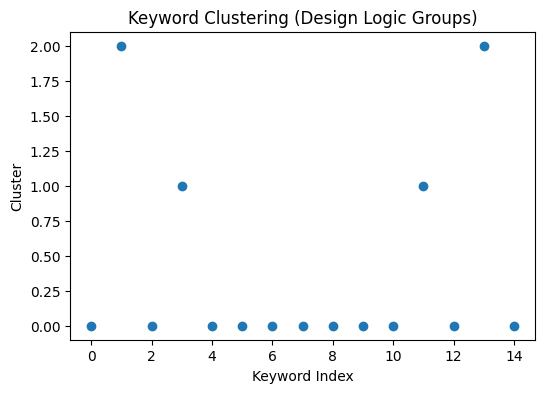

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(range(len(labels)), labels)
plt.title("Keyword Clustering (Design Logic Groups)")
plt.xlabel("Keyword Index")
plt.ylabel("Cluster")
plt.show()

In [6]:
cluster_meaning = {
    0: "Material System (thread, textile, weaving)",
    1: "Structural System (architecture, frame, support)",
    2: "Movement System (dance, flow, tension)"
}

df_api_like["cluster_meaning"] = df_api_like["cluster"].map(cluster_meaning)

display(df_api_like)

,keyword,generated_design_action,cluster,cluster_meaning
0,textile,create layered surfaces,0,"Material System (thread, textile, weaving)"
1,thread,extend linear elements through space,2,"Movement System (dance, flow, tension)"
2,pavilion,form temporary spatial frames,0,"Material System (thread, textile, weaving)"
3,architecture,organise lines into structural systems,1,"Structural System (architecture, frame, support)"
4,dance,translate motion into curved paths,0,"Material System (thread, textile, weaving)"
5,structure,increase support and connection points,0,"Material System (thread, textile, weaving)"
6,movement,generate directional flow,0,"Material System (thread, textile, weaving)"
7,body,respond to human scale and gesture,0,"Material System (thread, textile, weaving)"
8,knot,create dense connection nodes,0,"Material System (thread, textile, weaving)"
9,tension,pull elements between anchor points,0,"Material System (thread, textile, weaving)"


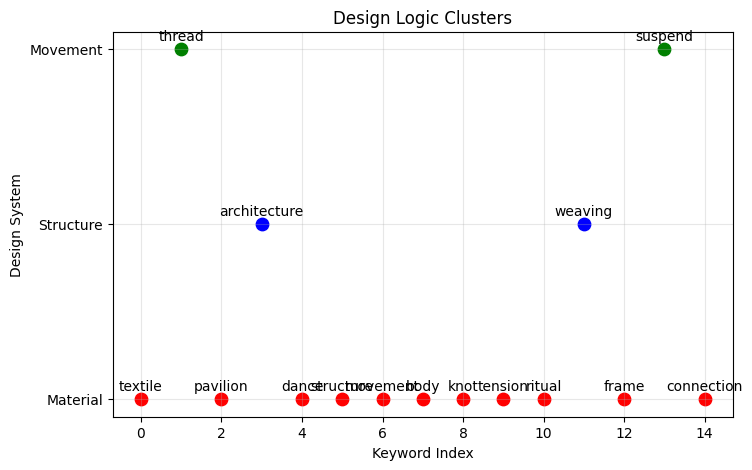

In [8]:
import matplotlib.pyplot as plt

colors = ["red", "blue", "green"]

plt.figure(figsize=(8,5))

for i in range(len(df_api_like)):
    cluster = df_api_like["cluster"][i]
    keyword = df_api_like["keyword"][i]
    
    plt.scatter(i, cluster, color=colors[cluster], s=80)
    plt.text(i, cluster+0.05, keyword, ha='center')

plt.yticks([0,1,2], ["Material", "Structure", "Movement"])

plt.title("Design Logic Clusters")
plt.xlabel("Keyword Index")
plt.ylabel("Design System")

plt.grid(alpha=0.3)
plt.show()

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.morphology import skeletonize

IMAGE_DIR = "artist_images"

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

results = []

for file in image_files:
    path = os.path.join(IMAGE_DIR, file)
    img = cv2.imread(path)

    if img is None:
        print("Skipped:", file)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # red ratio
    r = img_rgb[:, :, 0]
    g = img_rgb[:, :, 1]
    b = img_rgb[:, :, 2]

    red_mask = (r > 120) & (g < 100) & (b < 100)
    red_ratio = red_mask.sum() / red_mask.size

    # edge density
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # skeleton length
    skeleton = skeletonize(edges > 0)
    skeleton_length = np.sum(skeleton)

    results.append({
        "file": file,
        "red_ratio": red_ratio,
        "edge_density": edge_density,
        "skeleton_length": skeleton_length
    })

df_img = pd.DataFrame(results)

df_img.to_csv("red_thread_image_features.csv", index=False, encoding="utf-8-sig")

print("Images analysed:", len(df_img))
display(df_img.head())

Images analysed: 30


,file,red_ratio,edge_density,skeleton_length
0,image1.jpg,0.201508,0.030689,10091
1,image10.jpg,0.095171,0.083969,132231
2,image11.jpg,0.061603,0.075590,50195
3,image12.jpg,0.035535,0.077796,46683
4,image13.jpg,0.184179,0.071727,18185


In [2]:
import numpy as np

df_frag = df_img.copy().head(20).reset_index(drop=True)

def normalise(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

df_frag["red_n"] = normalise(df_frag["red_ratio"])
df_frag["edge_n"] = normalise(df_frag["edge_density"])
df_frag["skeleton_n"] = normalise(df_frag["skeleton_length"])

# 如果 df_api_like 已经存在，就用 cluster；如果不存在，就自动生成 0,1,2 循环
if "df_api_like" in globals():
    clusters = list(df_api_like["cluster"])
    keywords = list(df_api_like["keyword"])
else:
    clusters = [0, 1, 2]
    keywords = ["material", "structure", "movement"]

df_frag["fragment_id"] = range(len(df_frag))
df_frag["keyword"] = [keywords[i % len(keywords)] for i in range(len(df_frag))]
df_frag["cluster"] = [clusters[i % len(clusters)] for i in range(len(df_frag))]

df_frag["x"] = df_frag["fragment_id"] * 6
df_frag["y"] = df_frag["cluster"] * 8
df_frag["z"] = df_frag["skeleton_n"] * 10

df_frag["pipe_radius"] = 0.05 + df_frag["red_n"] * 0.35
df_frag["rib_count"] = (5 + df_frag["edge_n"] * 12).round().astype(int)
df_frag["height"] = 3 + df_frag["skeleton_n"] * 12
df_frag["twist"] = df_frag["cluster"] * 30 + df_frag["red_n"] * 45

df_frag.to_csv("gh_20_architectural_fragments.csv", index=False, encoding="utf-8-sig")

display(df_frag[[
    "fragment_id", "file", "keyword", "cluster",
    "x", "y", "z",
    "pipe_radius", "rib_count", "height", "twist"
]])

,fragment_id,file,keyword,cluster,x,y,z,pipe_radius,rib_count,height,twist
0,0,image1.jpg,material,0,0,0,0.291810,0.181896,6,3.350173,16.958088
1,1,image10.jpg,structure,1,6,8,7.135461,0.103797,8,11.562553,36.916779
2,2,image11.jpg,movement,2,12,16,2.538886,0.079143,8,6.046663,63.746960
3,3,image12.jpg,material,0,18,0,2.342104,0.059997,8,5.810525,1.285371
4,4,image13.jpg,structure,1,24,8,0.745327,0.169169,7,3.894392,45.321710
5,5,image14.jpg,movement,2,30,16,1.899850,0.142598,11,5.279820,71.905456
6,6,image15.jpg,material,0,36,0,0.427182,0.305524,6,3.512618,32.853040
7,7,image16.jpg,structure,1,42,8,1.190831,0.053068,11,4.428997,30.394428
8,8,image17.jpg,movement,2,48,16,4.283081,0.050000,12,8.139697,60.000000
9,9,image18.jpg,material,0,54,0,10.000000,0.265440,9,15.000000,27.699442


In [4]:
df_frag.to_csv("gh_20_architectural_fragments_REAL.csv", index=False)